# Data analysis

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
import seaborn as sns
from pathlib import Path
import yaml
from dual_pathway_model.directory_functions import *
from dual_pathway_model.plotting_functions import *

Testing
Plotting colors safely loaded


C:\Users\rsankar\Desktop\DualPathwayFigures\Repo20Feb2026\Dual_Pathway_RL_songbird\src\dual_pathway_model\plotting_functions.py:911: SyntaxWarning: "is" with 'str' literal. Did you mean "=="?
  if label_legend is 'Night change':


In [2]:
save_figs = False

In [3]:
wanted_parameters = ["BG_NOISE", 
                     "RA_NOISE", 
                     "LEARNING_RATE_HL",
                     "LEARNING_RATE_RL", 
                     "N_DISTRACTORS",
                     "ANNEALING",
                     "TARGET_WIDTH",
                     "REWARD_WINDOW",
                     "JUMP_FACTOR",
                     "JUMP_MID"] 
                     # expand here

In [4]:
HERE = Path.cwd()          # notebook directory
results_dir = HERE.parent / "Robustness" / "results"

result_folders = find_subdirectories(results_dir, absolute=True)

selected_folders = []
for folder in result_folders:
    param_name = extract_param_name(folder)
    print(param_name)
    if param_name in wanted_parameters:
        selected_folders.append(folder)

print(selected_folders)

ANNEALING
BG_NOISE
JUMP_FACTOR
JUMP_MID
LEARNING_RATE_HL
LEARNING_RATE_RL
N_DISTRACTORS
N_DISTRACTORS_old
RA_NOISE
REWARD_WINDOW
TARGET_WIDTH
[WindowsPath('C:/Users/rsankar/Desktop/DualPathwayFigures/Repo20Feb2026/Dual_Pathway_RL_songbird/Robustness/results/params_ANNEALING'), WindowsPath('C:/Users/rsankar/Desktop/DualPathwayFigures/Repo20Feb2026/Dual_Pathway_RL_songbird/Robustness/results/params_BG_NOISE'), WindowsPath('C:/Users/rsankar/Desktop/DualPathwayFigures/Repo20Feb2026/Dual_Pathway_RL_songbird/Robustness/results/params_JUMP_FACTOR'), WindowsPath('C:/Users/rsankar/Desktop/DualPathwayFigures/Repo20Feb2026/Dual_Pathway_RL_songbird/Robustness/results/params_JUMP_MID'), WindowsPath('C:/Users/rsankar/Desktop/DualPathwayFigures/Repo20Feb2026/Dual_Pathway_RL_songbird/Robustness/results/params_LEARNING_RATE_HL'), WindowsPath('C:/Users/rsankar/Desktop/DualPathwayFigures/Repo20Feb2026/Dual_Pathway_RL_songbird/Robustness/results/params_LEARNING_RATE_RL'), WindowsPath('C:/Users/rsankar/Des

In [5]:
terminal_performance = {}
meta = {}

for folder in selected_folders:
    param = extract_param_name(folder)
    if param == "N_DISTRACTORS":
        print(f"Processing {folder.name} with special handling for N_DISTRACTORS")
        nos_peaks_path = folder / "nos_peaks.npy"
        if nos_peaks_path.exists():
            nos_peaks = np.load(nos_peaks_path)
            print(f"Loaded nos_peaks for {folder.name}")
        else:
            print(f"⚠️ Missing nos_peaks.npy for {folder.name}")

    perf_path = folder / "terminal_performance.npy"
    meta_path = folder / "meta.yaml"

    if not perf_path.exists() or not meta_path.exists():
        print(f"⚠️ Skipping {folder.name} (missing files)")
        continue

    terminal_performance[param] = np.load(perf_path)

    with open(meta_path, "r") as f:
        meta[param] = yaml.safe_load(f)


Processing params_N_DISTRACTORS with special handling for N_DISTRACTORS
Loaded nos_peaks for params_N_DISTRACTORS


In [6]:
# for i in range(nos_peaks.shape[1]):
#     print(f"Input peaks: {meta['N_DISTRACTORS']['values'][i]+1:.0f} -> Output Peak Range: {np.min(nos_peaks[:, i]):.0f} - {np.max(nos_peaks[:, i]):.0f}")
# # print(np.min(nos_peaks, axis=0), np.max(nos_peaks, axis=0))

In [7]:
# # scatter plot nos peaks and box plot
# nos_peaks_x_vals = meta["N_DISTRACTORS"]["values"][:len(nos_peaks)]  # ensure matching lengths
# # sns.boxplot(nos_peaks, color='lightblue')
# sns.violinplot(nos_peaks, color='lightblue')
# sns.stripplot(nos_peaks, color='red', alpha=0.1)
# plt.xticks(ticks=range(len(nos_peaks_x_vals)), labels=nos_peaks_x_vals)
# plt.xlabel("Input Number of Distractors")
# plt.ylabel("Output number of Peaks")
# plt.title("Relationship between Number of Distractors and Nos Peaks")
# plt.grid()
# plt.show()

In [8]:
terminal_performance['BG_NOISE'].shape, meta['BG_NOISE'].keys()

((100, 7), dict_keys(['parameter', 'section', 'seeds', 'shape', 'values']))

In [9]:
# import numpy as np
# import matplotlib.pyplot as plt
# import seaborn as sns
# import matplotlib.patches as mpatches

# import plotting_params

# color_violin = 'lightgray'
# color_bar = 'grey'
# color_strip = 'black'


In [10]:
# def plot_results_violin(returns, params, label=None, xlabels=None):
#     returns = np.asarray(returns)
#     sorted_params = list(params)
#     n_values = len(sorted_params)

#     above_threshold2 = np.zeros(n_values)
#     data, labels_list = [], []

#     for i in range(n_values):
#         col = returns[:, i]
#         above_threshold2[i] = np.mean(col > 0.7)
#         data.extend(col)
#         labels_list.extend([sorted_params[i]] * len(col))

#     # --- Figure & layout ---
#     fig = plt.figure(
#         figsize=(1 * n_values + 2, 7),
#         constrained_layout=True
#     )
#     gs = fig.add_gridspec(
#         2, 2,
#         width_ratios=[6, 1.2],
#         height_ratios=[2, 5],
#         wspace=0.25,
#         hspace=0.15
#     )

#     # =======================
#     # Violin + strip plot
#     # =======================
#     ax1 = fig.add_subplot(gs[:, 0])

#     sns.violinplot(
#         x=labels_list,
#         y=data,
#         inner=None,
#         color=color_violin,
#         linewidth=0,
#         cut=0,
#         bw_adjust=0.5,
#         width=0.5,
#         ax=ax1
#     )

#     # Clip violins to right half
#     for c in ax1.collections:
#         if hasattr(c, "get_paths"):
#             for path in c.get_paths():
#                 verts = path.vertices
#                 x_center = np.median(verts[:, 0])
#                 verts[:, 0] = np.maximum(verts[:, 0], x_center)

#     strip = sns.stripplot(
#         x=labels_list,
#         y=data,
#         size=3,
#         color=color_strip,
#         alpha=0.9,
#         jitter=0.05,
#         ax=ax1
#     )

#     # Shift strip slightly left
#     for coll in strip.collections:
#         offsets = coll.get_offsets()
#         offsets[:, 0] -= 0.1
#         coll.set_offsets(offsets)

#     ax1.axhline(
#         0.7, 0.05, 0.95,
#         color='grey',
#         linestyle='--',
#         linewidth=1,
#         label='Global maxima threshold'
#     )

#     ax1.set_ylim(0, 1)
#     ax1.set_yticks([0, 0.7, 1])
#     ax1.set_yticklabels(['0', '0.7', '1'], fontsize=12)
#     ax1.set_ylabel('Terminal Performance', fontsize=16)

#     if label is not None:
#         ax1.set_xlabel(label, fontsize=16)

#     # 🔒 FIX: ticks BEFORE labels
#     ax1.set_xticks(range(n_values))
#     ax1.set_xticklabels(
#         xlabels if xlabels is not None else sorted_params,
#         fontsize=12
#     )

#     ax1.spines['top'].set_visible(False)
#     ax1.spines['right'].set_visible(False)
#     ax1.legend(loc='lower right', fontsize=11, frameon=False)

#     # =======================
#     # Success-rate bar plot
#     # =======================
#     ax2 = fig.add_subplot(gs[0, 1])
#     ax2.bar(
#         range(n_values),
#         above_threshold2 * 100,
#         color=color_bar
#     )

#     ax2.set_ylim(0, 100)
#     ax2.set_ylabel('Success Rate (%)', fontsize=12)

#     ax2.set_xticks(range(n_values))
#     ax2.set_xticklabels(
#         xlabels if xlabels is not None else sorted_params,
#         rotation=90,
#         ha='right',
#         va='center',
#         fontsize=10,
#         rotation_mode="anchor"
#     )

#     ax2.spines['top'].set_visible(False)
#     ax2.spines['right'].set_visible(False)

#     plt.show()


In [11]:

# # Example call
# plot_results_violin(
#     terminal_performance["BG_NOISE"], 
#     meta["BG_NOISE"]["values"],
#     big_xlabel="BG Noise Level",
#     print_success_rate=True
# )

# if save_figs:
#     save_figure('9_robustness_BG_NOISE', format="pdf", save=save_figs)


# plot_results_violin(
#     terminal_performance["RA_NOISE"], 
#     meta["RA_NOISE"]["values"],
#     big_xlabel="RA Noise Level"
# )

# if save_figs:
#     save_figure('9_robustness_RA_NOISE', format="pdf", save=save_figs)


# plot_results_violin(
#     terminal_performance["LEARNING_RATE_HL"], 
#     meta["LEARNING_RATE_HL"]["values"],
#     big_xlabel="HL Learning Rate"
# )

# if save_figs:
#     save_figure('9_robustness_HL_LEARNING_RATE', format="pdf", save=save_figs)


# plot_results_violin(
#     terminal_performance["LEARNING_RATE_RL"], 
#     meta["LEARNING_RATE_RL"]["values"],
#     big_xlabel="RL Learning Rate"
# )
# if save_figs:
#     save_figure('9_robustness_RL_LEARNING_RATE', format="pdf", save=save_figs)



# plot_results_violin(
#     terminal_performance["TARGET_WIDTH"], 
#     meta["TARGET_WIDTH"]["values"],
#     big_xlabel="Target Width"
# )

# if save_figs:
#     save_figure('9_robustness_TARGET_WIDTH', format="pdf", save=save_figs)


# plot_results_violin(
#     terminal_performance["REWARD_WINDOW"], 
#     meta["REWARD_WINDOW"]["values"],
#     big_xlabel="Reward Window"
# )

# if save_figs:
#     save_figure('9_robustness_REWARD_WINDOW', format="pdf", save=save_figs)

# plot_results_violin(
#     terminal_performance["JUMP_FACTOR"], 
#     meta["JUMP_FACTOR"]["values"],
#     big_xlabel="Jump Factor"

# )

# if save_figs:
#     save_figure('9_robustness_JUMP_FACTOR', format="pdf", save=save_figs)

# plot_results_violin(
#     terminal_performance["JUMP_MID"],
#     meta["JUMP_MID"]["values"],
#     big_xlabel="Jump Midpoint"
# )

# if save_figs:
#     save_figure('9_robustness_JUMP_MID', format="pdf", save=save_figs)

Figure saved as  Plots\figure_8_robustness.pdf


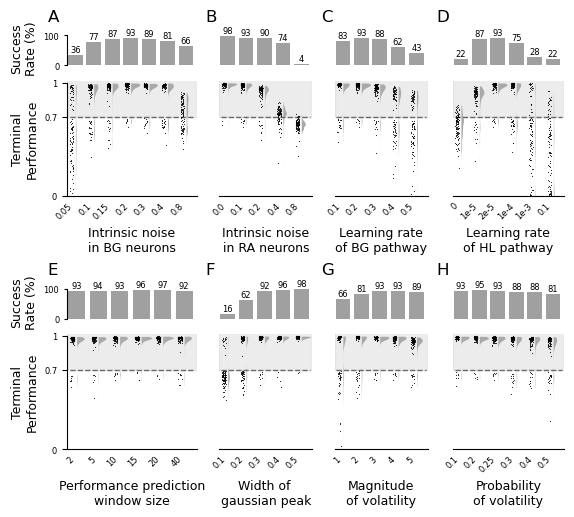

In [12]:
plt.rcParams.update({'font.family': 'sans-serif'})

# bar rows : violin rows = 3 : 10 — encoded directly in the layout string
# A-H = violin panels, 1-4 / 5-8 = matching success-rate bars
layout = """
1234
1234
1234
ABCD
ABCD
ABCD
ABCD
ABCD
ABCD
ABCD
ABCD
ABCD
ABCD
5678
5678
5678
EFGH
EFGH
EFGH
EFGH
EFGH
EFGH
EFGH
EFGH
EFGH
EFGH
"""

params_mosaic = [
    ("BG_NOISE",         "Intrinsic noise\nin BG neurons",        '1', 'A'),
    ("RA_NOISE",         "Intrinsic noise\nin RA neurons",         '2', 'B'),
    ("LEARNING_RATE_RL", "Learning rate\nof BG pathway",           '3', 'C'),
    ("LEARNING_RATE_HL", "Learning rate\nof HL pathway",           '4', 'D'),
    ("REWARD_WINDOW",    "Performance prediction\nwindow size",            '5', 'E'),
    ("TARGET_WIDTH",     "Width of \ngaussian peak",        '6', 'F'),
    ("JUMP_FACTOR",      "Magnitude\nof volatility",   '7', 'G'),
    ("JUMP_MID",         "Probability\nof volatility", '8', 'H'),
]

def fmt_sci(v):
    if v == 0:
        return '0'
    exp   = int(np.floor(np.log10(abs(v))))
    coeff = round(v / 10 ** exp)
    return f"{coeff}e{exp}"

def fmt_int(v):
    return str(int(v))

def fmt_decimal(v):
    return f"{v:.10f}".rstrip('0').rstrip('.')

LABEL_FORMATTERS = {
    "LEARNING_RATE_HL": fmt_sci,
    "REWARD_WINDOW":    fmt_int,
    "JUMP_FACTOR":      fmt_int,
}

THRESHOLD          = 0.7
color_violin       = 'darkgray'
color_bar          = 'grey'
color_strip        = 'black'
FONTSIZE_LABEL     = 9
FONTSIZE_BAR_LABEL = 9
FONTSIZE_TICK      = 6

fig_width  = 405 / 72
fig_height = fig_width * 0.9

# Column widths proportional to number of x-values so each bar has equal visual width
row1 = [p for p, _, bk, _ in params_mosaic if bk in '1234']
row2 = [p for p, _, bk, _ in params_mosaic if bk in '5678']
width_ratios = [
    max(len(meta[p1]["values"]), len(meta[p2]["values"]))
    for p1, p2 in zip(row1, row2)
]

fig, axs = plt.subplot_mosaic(
    layout,
    figsize=(fig_width, fig_height),
    layout="constrained",
    gridspec_kw={"width_ratios": width_ratios},
)

for col_idx, (param, xlabel, bar_key, vln_key) in enumerate(params_mosaic):
    ax_bar = axs[bar_key]
    ax_vln = axs[vln_key]
    col    = col_idx % 4

    returns    = np.asarray(terminal_performance[param])
    param_vals = meta[param]["values"]
    n          = len(param_vals)

    above_threshold = np.array([np.mean(returns[:, i] > THRESHOLD) for i in range(n)])

    data, labels_list = [], []
    for i in range(n):
        data.extend(returns[:, i])
        labels_list.extend([param_vals[i]] * returns.shape[0])

    fmt = LABEL_FORMATTERS.get(param)
    xticklabels = [fmt(v) for v in param_vals] if fmt else list(param_vals)
    if param == "LEARNING_RATE_HL":
        xticklabels[0]  = fmt_decimal(param_vals[0])
        xticklabels[-1] = fmt_decimal(param_vals[-1])

    # --- Violin ---
    ax_vln.axhspan(THRESHOLD, 1.05, alpha=0.15, color='grey')
    sns.violinplot(x=labels_list, y=data, inner=None, color=color_violin,
                   linewidth=0, cut=0, bw_adjust=0.5, width=1, ax=ax_vln)
    for c in ax_vln.collections:
        if hasattr(c, "get_paths"):
            for path in c.get_paths():
                verts = path.vertices
                verts[:, 0] = np.maximum(verts[:, 0], np.median(verts[:, 0]))
    strip = sns.stripplot(x=labels_list, y=data, size=0.8, color=color_strip,
                          alpha=0.9, jitter=0.1, ax=ax_vln)
    for coll in strip.collections:
        offsets = coll.get_offsets()
        offsets[:, 0] -= 0.2
        coll.set_offsets(offsets)
    ax_vln.axhline(THRESHOLD, 0.02, 0.98, color='dimgray', linestyle='--', linewidth=1)
    ax_vln.set_ylim(0, 1.015)
    ax_vln.set_yticks([0, THRESHOLD, 1])
    ax_vln.set_xlim(-0.45, n - 0.4)
    ax_vln.set_xticks(np.arange(n) - 0.05)
    ax_vln.set_xticklabels(xticklabels, fontsize=FONTSIZE_TICK, rotation=45, ha='right')
    ax_vln.tick_params(axis='x', length=0)
    ax_vln.set_xlabel(xlabel, fontsize=FONTSIZE_LABEL)
    ax_vln.spines['top'].set_visible(False)
    ax_vln.spines['right'].set_visible(False)
    if col == 0:
        ax_vln.spines['left'].set_bounds(0, 1)
        ax_vln.set_yticklabels(['0', '0.7', '1'], fontsize=FONTSIZE_TICK)
        ax_vln.set_ylabel('Terminal\nPerformance', fontsize=FONTSIZE_LABEL)
    else:
        ax_vln.spines['left'].set_visible(False)
        ax_vln.tick_params(axis='y', left=False)
        ax_vln.set_yticklabels([])
        ax_vln.set_ylabel('')

    # --- Success-rate bar ---
    ax_bar.bar(range(n), above_threshold * 100, color=color_bar, alpha=0.75)
    for i, val in enumerate(above_threshold * 100):
        ax_bar.text(i, val + 3, f"{int(val)}",
                    ha='center', va='bottom', fontsize=6)
    ax_bar.set_ylim(0, 115)
    ax_bar.set_xticks([])
    ax_bar.set_xlim(-0.45, n - 0.4)
    ax_bar.spines['top'].set_visible(False)
    ax_bar.spines['right'].set_visible(False)
    ax_bar.spines['bottom'].set_visible(False)
    if col == 0:
        ax_bar.tick_params(axis='y', length=2, labelsize=FONTSIZE_TICK)
        ax_bar.set_yticks([0, 100])
        ax_bar.set_yticklabels(['0', '100'], fontsize=FONTSIZE_TICK)
        ax_bar.set_ylabel('Success\nRate (%)', fontsize=FONTSIZE_BAR_LABEL)
        ax_bar.spines['left'].set_bounds(0, 100)
    else:
        ax_bar.spines['left'].set_visible(False)
        ax_bar.tick_params(axis='y', left=False)
        ax_bar.set_yticks([])
        ax_bar.set_ylabel('')

    # Panel label (A–H) — shifted left of subplot boundary
    ax_bar.text(-0.15, 1.2, vln_key, transform=ax_bar.transAxes,
                fontsize=12, va='bottom', ha='left')

fig.align_xlabels([axs[k] for k in 'ABCDEFGH'])
# plt.tight_layout()
save_figure('figure_8_robustness', format="pdf", save=True, dpi=600)
plt.show()


In [13]:
raise SystemExit("Old code")

SystemExit: Old code

c:\ProgramData\anaconda3\envs\dual_pathway_env\Lib\site-packages\IPython\core\interactiveshell.py:3707: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


In [ ]:
# plot_results_violin(
#     terminal_performance["N_DISTRACTORS"], 
#     meta["N_DISTRACTORS"]["values"],
#     big_xlabel="Number of Distractors"
# )

# if save_figs:
#     save_figure('9_robustness_N_DISTRACTORS', format="pdf", save=save_figs)

# plot_results_violin(
#     terminal_performance["ANNEALING"], 
#     meta["ANNEALING"]["values"],
#     big_xlabel="Annealing"
# )

# if save_figs:
#     save_figure('9_robustness_ANNEALING', format="pdf", save=save_figs)